# Kinetic onset temperature of the Er$^{3+}$ Boltzmann thermometer

Feasibility check for the paper proposal: does `AndersonModelUnfolded`, parameterized from Anderson (2013) at room temperature and Suta (2025), reproduce Suta's onset temperature $T_{on}$ **without** using it as an input, and how does $T_{on}$ depend on excitation power?

Model state used here:
- $^2H_{11/2}$ (Er6h) 650 cm$^{-1}$ above $^4S_{3/2}$ (Er6s), from Suta's 77 K excitation spectra.
- 6s $\leftrightarrow$ 6h coupling with Suta's $k_{nr}(0) = 2.29\ \mu s^{-1}$ (`k_therm`), each rate carrying the degeneracy of its final level: $k_{down} = g_s k_{nr}(0)(1+n)^p$, $k_{up} = g_h k_{nr}(0)\, n^p$, $g_s = 4$, $g_h = 12$.
- $k_{r6h}/k_{r6s} = C = 5.52/3$ (Suta's LIR fit), split so that the model reduces to Anderson's $k_{r6}$ at $T_0 = 300$ K.
- Er–Er cross relaxation from level 6 (CR6) phonon-assisted: its 1600 cm$^{-1}$ mismatch is emitted as phonons, so it scales as $(1+n)^p$ from Anderson's value at $T_0$.
- A single effective phonon energy $\hbar\omega$ (`phonon_wavenumber`) for every multiphonon process, including the 6s $\leftrightarrow$ 6h coupling ($p = 650/\hbar\omega$).

In [1]:
import warnings

import numpy as np
from matplotlib import pyplot as plt
from pint import get_application_registry
from poincare import solvers

from upconversion_models import AndersonModel, AndersonModelUnfolded as M, cmap
from upconversion_models.jablonski_patch import EmissionTransform, Simulator, SteadyState

warnings.filterwarnings("ignore")
u = get_application_registry()

hc_k = 1.4388  # cm K
gap = 650  # cm-1, Er6h - Er6s
C = (M.k_r6h.default / M.k_r6s.default).to("").magnitude

# Suta 2025
suta_k1, suta_tau = 2430, 0.41e-3  # 1/s, s (4S3/2 at 77 K)
suta_Ton, suta_Ton_err = 100, 5  # K
suta_P = 5.5e-3  # W/cm2

sim = (
    Simulator(M())
    .with_transform(EmissionTransform("emission"), append=True)
    .with_solver(solvers.LSODA(rtol=1e-10, atol=1e-18))
)
steady = SteadyState()

### Observables

**$k_1$ at 77 K.** Suta measured the 4S3/2 decay after direct excitation into 2H11/2 (515 nm) and reports the intensity-weighted average $\langle\tau\rangle = 0.41$ ms, $k_1 = 1/\langle\tau\rangle$. We reproduce the experiment: no NIR pump, a small initial population in Er6h, and
$$\langle\tau\rangle = \frac{\int t\, I(t)\, dt}{\int I(t)\, dt}, \qquad I = \text{line\_rad6s1}$$

**$T_{on}$.** Since Er6s is fed only from Er6h, the model reduces to
$$\text{LIR} = C\left[\frac{g_h}{g_s} e^{-\Delta E/kT} + \frac{k_1(T,P)}{k_{21}(T)}\right]$$
$T_{on}$ is where the kinetic floor equals the Boltzmann term, i.e. LIR $= 2\times$ Boltzmann. This is the condition behind Suta's eq. 6, $g_h k_{nr}(0)\, n(T_{on})^p = k_1$.

In [2]:
def k1_direct(s, T, t_end=5e-3, n=20001):
    t = np.linspace(0, t_end, n)
    ds = s.with_values({M.T: T * u.K, M.Er6h: 1e-8}).solve(save_at=t * u.s).pint.dequantify()
    I = ds["line_rad6s1"].values
    return np.trapezoid(I, t) / np.trapezoid(t * I, t)


def boltzmann(T):
    return C * 12 / 4 * np.exp(-gap * hc_k / T)


def onset(s, P, Ts=np.arange(40, 310, 10.0)):
    ds = steady.sweep(
        s.with_values({M.energy_flux: P * u.W / u.cm**2}), variable=M.T, values=Ts * u.K
    )
    excess = (ds["line_rad6h1"] / ds["line_rad6s1"]).values / boltzmann(Ts) - 1
    # excess decreases with T; interpolate log(excess) = 0
    j = np.where(excess > 1)[0].max()
    x0, x1 = np.log(excess[j]), np.log(excess[j + 1])
    return Ts[j] + (Ts[j + 1] - Ts[j]) * (-x0) / (x1 - x0)

### Sweep of the effective phonon energy

$\hbar\omega$ enters $k_1(77\,K)$ mostly through the phonon-assisted CR6 ($p = 1600/\hbar\omega$, anchored at 300 K) and $T_{on}$ also through the 6s $\leftrightarrow$ 6h coupling ($p = 650/\hbar\omega$). At $T_0$ nothing depends on it.

Caveat: Suta extracted $k_{nr}(0)$ assuming $p = 2$ ($\hbar\omega_{eff} = 325$ cm$^{-1}$). For $\hbar\omega \neq 325$ cm$^{-1}$ the same number means a slightly different coupling.

In [3]:
phonons = np.array([200, 225, 250, 275, 298, 325, 350, 400, 450])
k1_77 = []
Ton = []
for w in phonons:
    s = sim.with_values({M.phonon_wavenumber: w / u.cm})
    k1_77.append(k1_direct(s, 77))
    Ton.append(onset(s, suta_P))
k1_77, Ton = np.array(k1_77), np.array(Ton)

for w, k, t in zip(phonons, k1_77, Ton):
    print(f"hw = {w:3d} cm-1   k1(77 K) = {k:6.0f} 1/s   <tau> = {1e3 / k:.3f} ms   T_on = {t:5.1f} K")

hw = 200 cm-1   k1(77 K) =   1566 1/s   <tau> = 0.639 ms   T_on =  94.7 K
hw = 225 cm-1   k1(77 K) =   1801 1/s   <tau> = 0.555 ms   T_on =  96.7 K
hw = 250 cm-1   k1(77 K) =   2157 1/s   <tau> = 0.464 ms   T_on =  98.8 K
hw = 275 cm-1   k1(77 K) =   2613 1/s   <tau> = 0.383 ms   T_on = 101.0 K
hw = 298 cm-1   k1(77 K) =   3092 1/s   <tau> = 0.323 ms   T_on = 103.1 K
hw = 325 cm-1   k1(77 K) =   3688 1/s   <tau> = 0.271 ms   T_on = 105.2 K
hw = 350 cm-1   k1(77 K) =   4240 1/s   <tau> = 0.236 ms   T_on = 106.9 K
hw = 400 cm-1   k1(77 K) =   5262 1/s   <tau> = 0.190 ms   T_on = 109.4 K
hw = 450 cm-1   k1(77 K) =   6110 1/s   <tau> = 0.164 ms   T_on = 111.4 K


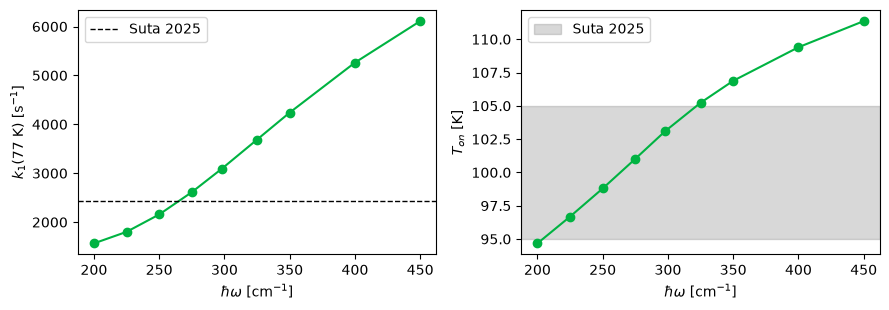

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))

ax1.plot(phonons, k1_77, "o-", color=cmap["g"])
ax1.axhline(suta_k1, color="black", ls="--", lw=1, label="Suta 2025")
ax1.set_xlabel(r"$\hbar\omega$ [cm$^{-1}$]")
ax1.set_ylabel(r"$k_1$(77 K) [s$^{-1}$]")
ax1.legend()

ax2.plot(phonons, Ton, "o-", color=cmap["g"])
ax2.axhspan(suta_Ton - suta_Ton_err, suta_Ton + suta_Ton_err, color="gray", alpha=0.3, label="Suta 2025")
ax2.set_xlabel(r"$\hbar\omega$ [cm$^{-1}$]")
ax2.set_ylabel(r"$T_{on}$ [K]")
ax2.legend()

fig.tight_layout()
plt.show()

### Onset temperature vs excitation power

Above Suta's power density the ETU out of 4S3/2 (6s $\to$ 9) adds to $k_1$, so $T_{on}$ should rise. Compared for the $\hbar\omega$ that best matches Suta's $k_1$ and for the current default (298 cm$^{-1}$).

best hw = 275 cm-1
P =   0.0055 W/cm2   T_on(hw=275) = 101.0 K   T_on(hw=298) = 103.1 K
P =      0.1 W/cm2   T_on(hw=275) = 101.4 K   T_on(hw=298) = 103.5 K
P =        1 W/cm2   T_on(hw=275) = 104.5 K   T_on(hw=298) = 106.1 K
P =        3 W/cm2   T_on(hw=275) = 108.4 K   T_on(hw=298) = 109.5 K
P =       10 W/cm2   T_on(hw=275) = 114.9 K   T_on(hw=298) = 115.7 K
P =       30 W/cm2   T_on(hw=275) = 122.1 K   T_on(hw=298) = 122.5 K
P =      100 W/cm2   T_on(hw=275) = 131.4 K   T_on(hw=298) = 131.6 K
P =      300 W/cm2   T_on(hw=275) = 141.3 K   T_on(hw=298) = 141.4 K


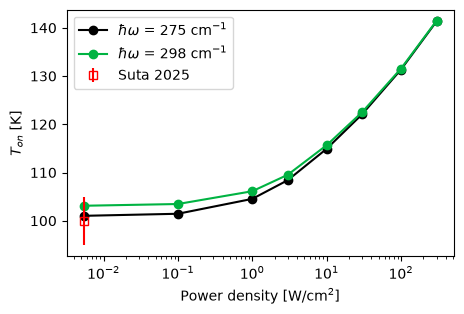

In [5]:
best = phonons[np.argmin(np.abs(np.log(k1_77 / suta_k1)))]
powers = np.array([suta_P, 0.1, 1, 3, 10, 30, 100, 300])

Ton_P = {}
for w in sorted({best, 298}):
    s = sim.with_values({M.phonon_wavenumber: w / u.cm})
    Ton_P[w] = np.array([onset(s, P) for P in powers])

print(f"best hw = {best} cm-1")
for i, P in enumerate(powers):
    print(f"P = {P:8.4g} W/cm2   " + "   ".join(f"T_on(hw={w}) = {Ton_P[w][i]:5.1f} K" for w in Ton_P))

fig, ax = plt.subplots(figsize=(5, 3.2))
for w, color in zip(Ton_P, ["black", cmap["g"]]):
    ax.semilogx(powers, Ton_P[w], "o-", color=color, label=rf"$\hbar\omega$ = {w} cm$^{{-1}}$")
ax.errorbar([suta_P], [suta_Ton], yerr=[suta_Ton_err], fmt="s", color=cmap["r"], mfc="none", label="Suta 2025")
ax.set_xlabel(r"Power density [W/cm$^2$]")
ax.set_ylabel(r"$T_{on}$ [K]")
ax.legend()
plt.show()

### Consistency with Anderson at $T_0$

At 300 K every temperature factor is 1, so the unfolded model, with the 6s and 6h lines recombined, should match `AndersonModel`.

In [6]:
anderson = (
    Simulator(AndersonModel())
    .with_transform(EmissionTransform("emission"), append=True)
    .with_solver(solvers.LSODA(rtol=1e-10, atol=1e-18))
)


def value(ds, key):
    v = ds[key].item()
    return getattr(v, "magnitude", v)


for P in [1, 5, 50]:
    a = steady.solve(anderson.with_values({AndersonModel.energy_flux: P * u.W / u.cm**2}))
    m = steady.solve(sim.with_values({M.energy_flux: P * u.W / u.cm**2}))
    green = (value(m, "line_rad6s1") + value(m, "line_rad6h1")) / value(a, "line_rad61")
    red = value(m, "line_rad51") / value(a, "line_rad51")
    blue = value(m, "line_rad81") / value(a, "line_rad81")
    print(f"P = {P:3d} W/cm2   unfolded / Anderson:  green {green:.4f}   red {red:.4f}   blue {blue:.4f}")

P =   1 W/cm2   unfolded / Anderson:  green 0.9990   red 1.0130   blue 0.9934


P =   5 W/cm2   unfolded / Anderson:  green 0.9991   red 1.0154   blue 0.9948


P =  50 W/cm2   unfolded / Anderson:  green 0.9994   red 1.0177   blue 0.9969


### Summary

- Suta's $k_1 = 2430$ s$^{-1}$ at 77 K falls between $\hbar\omega = 250$ and $275$ cm$^{-1}$ (≈ 265 cm$^{-1}$ by interpolation). With 298 cm$^{-1}$ (Suyver's lowest dominant Raman mode) the model gives $\langle\tau\rangle = 0.32$ ms vs 0.41 ms measured. Without phonon-assisted CR6 it was 0.11 ms.
- $T_{on}$ at Suta's power is weakly sensitive to $\hbar\omega$: 95–111 K over 200–450 cm$^{-1}$, and 101 K at 275 cm$^{-1}$, inside Suta's $100 \pm 5$ K. Neither $T_{on}$ nor $k_1$ was used as input.
- $T_{on}$ rises with power, from ≈ 101 K at 5.5 mW/cm$^2$ to ≈ 141 K at 300 W/cm$^2$, independently of $\hbar\omega$ above ~10 W/cm$^2$: there the ETU out of 4S3/2 dominates $k_1$.
- At $T_0$ the model matches Anderson within 0.1 % in green, but red is 1.3–1.8 % high and blue 0.3–0.7 % low. Still to be traced (suspect: detailed-balance upward partners such as 8 → 9).

## Splitting CR6 between 4S3/2 and 2H11/2

Anderson lumps level 6, so his $k_{cr6}$ only fixes the population-weighted combination at $T_0$. With $f_s$ the Boltzmann fraction of the manifold in 4S3/2

$$
f_s(T) = \frac{1}{1 + \frac{g_h}{g_s} e^{-\Delta E / kT}}, \qquad
f_s(T_0)\, k_{cr6s} + \big(1 - f_s(T_0)\big)\, k_{cr6h} = k_{cr6}
$$

with $f_s(300\ \text{K}) = 0.883$. Any $x = k_{cr6s}/k_{cr6}$ in $[0, 1/f_s(T_0)]$ keeps the model equal to Anderson's at $T_0$, with $k_{cr6h}/k_{cr6} = (1 - f_s x)/(1 - f_s)$. Up to here $x = 1$ (equal split).

At 77 K the manifold sits entirely in 4S3/2, so Suta's $k_1$ sees $k_{cr6s}$ only. Here $x$ is fixed by $k_1(77\ \text{K}) = 2430$ s$^{-1}$, keeping $\hbar\omega = 298$ cm$^{-1}$ and the CR6 target at Er3, as in Anderson. A lower $k_{cr6s}$ forces a higher $k_{cr6h}$, which matters above ~200 K, where $1 - f_s$ grows. The values are passed with `with_values`; the model defaults are untouched.

In [7]:
from scipy.optimize import brentq

fs0 = 1 / (1 + 3 * np.exp(-gap * hc_k / M.T0.default.to("K").magnitude))
k_cr6 = M.k_cr6.default.to("cm**3/s").magnitude


def cr6_split(x):
    # k_cr6s = x k_cr6, k_cr6h from Anderson's constraint at T0
    return {
        M.k_cr6s: x * k_cr6 * u.cm**3 / u.s,
        M.k_cr6h: (1 - fs0 * x) / (1 - fs0) * k_cr6 * u.cm**3 / u.s,
    }


x_suta = brentq(lambda x: k1_direct(sim.with_values(cr6_split(x)), 77) - suta_k1, 0, 1 / fs0, xtol=1e-6)
x_h = (1 - fs0 * x_suta) / (1 - fs0)

splits = {"equal": sim.with_values(cr6_split(1.0)), "Suta-fixed": sim.with_values(cr6_split(x_suta))}

print(f"fs(T0) = {fs0:.4f}")
print(f"k_cr6s = {x_suta:.3f} k_cr6 = {x_suta * k_cr6:.3e} cm3/s")
print(f"k_cr6h = {x_h:.3f} k_cr6 = {x_h * k_cr6:.3e} cm3/s")
print(f"k1(77 K) = {k1_direct(splits['Suta-fixed'], 77):.0f} 1/s (Suta {suta_k1}),  equal split {k1_direct(splits['equal'], 77):.0f} 1/s")

fs(T0) = 0.8828
k_cr6s = 0.614 k_cr6 = 1.713e-17 cm3/s
k_cr6h = 3.906 k_cr6 = 1.090e-16 cm3/s


k1(77 K) = 2430 1/s (Suta 2430),  equal split 3092 1/s


Anderson's consistency at $T_0$ for both splits (6s + 6h recombined for the green):

In [8]:
for name, s in splits.items():
    for P in [1, 5, 50]:
        a = steady.solve(anderson.with_values({AndersonModel.energy_flux: P * u.W / u.cm**2}))
        m = steady.solve(s.with_values({M.energy_flux: P * u.W / u.cm**2}))
        green = (value(m, "line_rad6s1") + value(m, "line_rad6h1")) / value(a, "line_rad61")
        red = value(m, "line_rad51") / value(a, "line_rad51")
        blue = value(m, "line_rad81") / value(a, "line_rad81")
        print(f"{name:10s}  P = {P:3d} W/cm2   unfolded / Anderson:  green {green:.4f}   red {red:.4f}   blue {blue:.4f}")

equal       P =   1 W/cm2   unfolded / Anderson:  green 0.9990   red 1.0130   blue 0.9934


equal       P =   5 W/cm2   unfolded / Anderson:  green 0.9991   red 1.0154   blue 0.9948


equal       P =  50 W/cm2   unfolded / Anderson:  green 0.9994   red 1.0177   blue 0.9969


Suta-fixed  P =   1 W/cm2   unfolded / Anderson:  green 0.9981   red 1.0123   blue 0.9926


Suta-fixed  P =   5 W/cm2   unfolded / Anderson:  green 0.9982   red 1.0147   blue 0.9941


Suta-fixed  P =  50 W/cm2   unfolded / Anderson:  green 0.9985   red 1.0169   blue 0.9964


### Independent test against Yu 2014

Yu et al. (2014) measured bulk $\beta$-NaYF$_4$:18%Yb,2%Er (Anderson's composition) between 10 and 400 K under 290 W/cm$^2$ (2.9 W/mm$^2$) at 980 nm. Data, experimental conditions and observables are those of `claude/paper2.ipynb`, here with `AndersonModelUnfolded` and nothing refitted:

- **Fig 7.** After a 10 ns pulse at 980 nm Yu fits the 4S3/2 line with $I = I_1 e^{-t/\tau_D} - I_2 e^{-t/\tau_R}$. The time of the maximum
$$t_{max} = \frac{\tau_D \tau_R}{\tau_D - \tau_R} \ln\frac{\tau_D}{\tau_R}$$
is defined for any curve, so the model's $t_{max}$ is compared with the one implied by Yu's fit. The simulated curve is also fitted with Yu's function to get a $\tau_R$ directly. Yu does not report the pulse energy: 10 and 30 mJ/cm$^2$, as in `paper2`.
- **Fig 4b.** Steady-state 541 nm (4S3/2, `line_rad6s1`) intensity relative to 300 K.
- **Fig 5c, 5d.** $R_{HS}$ = `line_rad6h1/line_rad6s1` (absolute) and $R_{r/g}$ = `line_rad51/(line_rad6s1 + line_rad6h1)` (relative to 300 K).

Between 300 and 400 K the green is set by the depopulation rate of the thermalized manifold,
$$k_{eff}(T) \approx k_{r} + \big[f_s(T)\, k_{cr6s} + (1 - f_s(T))\, k_{cr6h}\big] N_{1} \left[\frac{1 + n(T)}{1 + n(T_0)}\right]^{p} + \dots$$
The Suta-fixed split moves CR6 weight to 2H11/2, whose share $1 - f_s$ grows with $T$, so $k_{eff}$ should rise faster than with the equal split. The pump-free decay rate of 4S3/2 ($k_1$ from `k1_direct`) measures $k_{eff}$ directly. Yu's $\tau_R(300)/\tau_R(400) = 88/45 = 1.96$.

In [9]:
import pandas as pd
from IPython.display import display
from scipy.optimize import curve_fit

from upconversion_models.jablonski_patch import PulsedExcitation

# Yu 2014, bulk sample, transcribed in claude/paper2.ipynb
yu = pd.DataFrame(
    {
        "S": [2.9e4, 3.4e4, 3.65e4, 5.3e4, 4.25e4, 2.7e4, 2.4e4, 1.55e4, 1.1e4, 1.05e4],
        "R_HS": [0, 0, 0, 0, 0.02, 0.12, 0.23, 0.30, 0.58, 0.80],
        "R_rg": [0.21, 0.22, 0.22, 0.19, 0.20, 0.20, 0.31, 0.35, 0.68, 1.0],
    },
    index=pd.Index([10, 30, 50, 100, 150, 200, 250, 300, 350, 400], name="T"),
)
yu_lifetimes = pd.DataFrame(
    {
        "tauR_S3/2": [162, 190, 190, 162, 181, 139, 128, 88, 65, 45],
        "tauD_S3/2": [980, 940, 930, 895, 885, 795, 800, 720, 705, 700],
    },
    index=yu.index,
)  # µs, Fig 7


def t_max(tau_d, tau_r):
    return tau_d * tau_r / (tau_d - tau_r) * np.log(tau_d / tau_r)


def rise_decay(t, A, tau_d, tau_r):
    return A * (np.exp(-t / tau_d) - np.exp(-t / tau_r))


yu["tmax"] = t_max(yu_lifetimes["tauD_S3/2"], yu_lifetimes["tauR_S3/2"])
yu["tauR"] = yu_lifetimes["tauR_S3/2"]
Ts_yu = yu.index.to_numpy()

pulse_width = 10e-9 * u.s
fluences = [10, 30]  # mJ/cm2
t_pulse = np.linspace(0, 4e-3, 4001) * u.s

results = {}
for name, s in splits.items():
    ds = steady.sweep(s.with_values({M.energy_flux: 290 * u.W / u.cm**2}), variable=M.T, values=Ts_yu * u.K)
    df = pd.DataFrame(
        {
            "S": ds["line_rad6s1"].values,
            "R_HS": (ds["line_rad6h1"] / ds["line_rad6s1"]).values,
            "R_rg": (ds["line_rad51"] / (ds["line_rad6s1"] + ds["line_rad6h1"])).values,
            "k1": [k1_direct(s, T) for T in Ts_yu],
        },
        index=yu.index,
    )
    for F in fluences:
        pulse = PulsedExcitation(
            pulse_width=pulse_width, pulse_height=F * u.mJ / u.cm**2 / pulse_width, pump="energy_flux"
        )
        tmax, tauR = [], []
        for T in Ts_yu:
            res = pulse.solve(s.with_values({M.T: T * u.K}), save_at=t_pulse).pint.dequantify().to_dataframe()
            t, y = res.index.to_numpy() * 1e6, res["line_rad6s1"].to_numpy()
            y = y / y.max()
            tmax.append(t[np.argmax(y)])
            popt, _ = curve_fit(rise_decay, t, y, p0=(2, 700, tmax[-1] / 2), maxfev=20000)
            tauR.append(min(popt[1:]))
        df[f"tmax_{F}"], df[f"tauR_{F}"] = tmax, tauR
    results[name] = df

for name, df in results.items():
    print(f"{name:10s}  pump-free k1(400 K) / k1(300 K) = {df.loc[400, 'k1'] / df.loc[300, 'k1']:.2f}")

equal       pump-free k1(400 K) / k1(300 K) = 2.17
Suta-fixed  pump-free k1(400 K) / k1(300 K) = 3.24


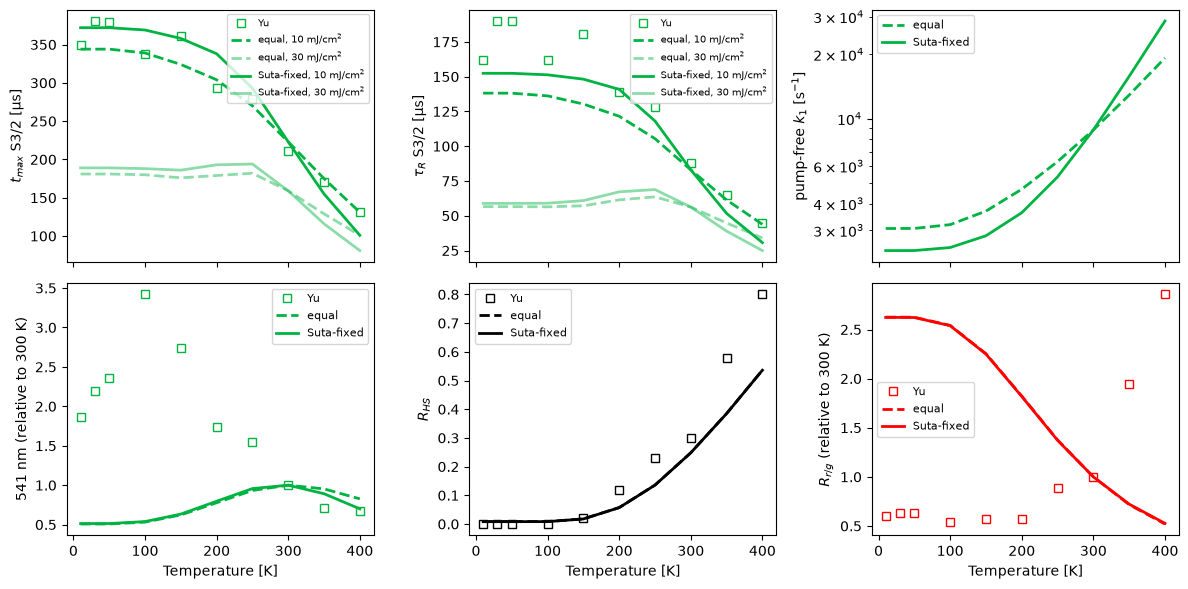

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
styles = {"equal": "--", "Suta-fixed": "-"}

for ax, metric, label in [(axs[0, 0], "tmax", r"$t_{max}$ S3/2 [µs]"), (axs[0, 1], "tauR", r"$\tau_R$ S3/2 [µs]")]:
    ax.plot(yu.index, yu[metric], "s", color=cmap["g"], mfc="none", label="Yu")
    for name, df in results.items():
        for F, alpha in zip(fluences, [1, 0.45]):
            ax.plot(df.index, df[f"{metric}_{F}"], ls=styles[name], color=cmap["g"], alpha=alpha, lw=2,
                    label=f"{name}, {F} mJ/cm$^2$")
    ax.set_ylabel(label)
    ax.legend(fontsize=7)

ax = axs[0, 2]
for name, df in results.items():
    ax.semilogy(df.index, df["k1"], ls=styles[name], color=cmap["g"], lw=2, label=name)
ax.set_ylabel(r"pump-free $k_1$ [s$^{-1}$]")
ax.legend(fontsize=8)

ax = axs[1, 0]
ax.plot(yu.index, yu["S"] / yu.loc[300, "S"], "s", color=cmap["g"], mfc="none", label="Yu")
for name, df in results.items():
    ax.plot(df.index, df["S"] / df.loc[300, "S"], ls=styles[name], color=cmap["g"], lw=2, label=name)
ax.set_ylabel("541 nm (relative to 300 K)")
ax.legend(fontsize=8)

ax = axs[1, 1]
ax.plot(yu.index, yu["R_HS"], "s", color="black", mfc="none", label="Yu")
for name, df in results.items():
    ax.plot(df.index, df["R_HS"], ls=styles[name], color="black", lw=2, label=name)
ax.set_ylabel(r"$R_{HS}$")
ax.legend(fontsize=8)

ax = axs[1, 2]
ax.plot(yu.index, yu["R_rg"] / yu.loc[300, "R_rg"], "s", color=cmap["r"], mfc="none", label="Yu")
for name, df in results.items():
    ax.plot(df.index, df["R_rg"] / df.loc[300, "R_rg"], ls=styles[name], color=cmap["r"], lw=2, label=name)
ax.set_ylabel(r"$R_{r/g}$ (relative to 300 K)")
ax.legend(fontsize=8)

for ax in axs[1]:
    ax.set_xlabel("Temperature [K]")
fig.tight_layout()
plt.show()

In [11]:
def rms_log(model, data):
    return np.sqrt(np.mean(np.log10(np.asarray(model, float) / np.asarray(data, float)) ** 2))


hot = yu.index >= 200
rows = {}
for name, df in results.items():
    row = {}
    rel_S, rel_Syu = df["S"] / df.loc[300, "S"], yu["S"] / yu.loc[300, "S"]
    row["S rel, 10-400 K"] = rms_log(rel_S, rel_Syu)
    row["S rel, 200-400 K"] = rms_log(rel_S[hot], rel_Syu[hot])
    for F in fluences:
        row[f"tmax {F} mJ, 10-400 K"] = rms_log(df[f"tmax_{F}"], yu["tmax"])
        row[f"tmax {F} mJ, 200-400 K"] = rms_log(df[f"tmax_{F}"][hot], yu["tmax"][hot])
        row[f"tauR {F} mJ, 10-400 K"] = rms_log(df[f"tauR_{F}"], yu["tauR"])
        row[f"tauR {F} mJ, 200-400 K"] = rms_log(df[f"tauR_{F}"][hot], yu["tauR"][hot])
    pos = yu["R_HS"] > 0
    row["R_HS, 150-400 K"] = rms_log(df["R_HS"][pos], yu["R_HS"][pos])
    row["R_rg rel, 10-400 K"] = rms_log(df["R_rg"] / df.loc[300, "R_rg"], yu["R_rg"] / yu.loc[300, "R_rg"])
    rows[name] = row
print("rms log10 deviation from Yu")
display(pd.DataFrame(rows).round(3))


def ratios(df, tmax, tauR):
    return {
        "tmax(300)/tmax(400), 10 mJ": df.loc[300, tmax[0]] / df.loc[400, tmax[0]],
        "tmax(300)/tmax(400), 30 mJ": df.loc[300, tmax[1]] / df.loc[400, tmax[1]],
        "tauR(300)/tauR(400), 10 mJ": df.loc[300, tauR[0]] / df.loc[400, tauR[0]],
        "tauR(300)/tauR(400), 30 mJ": df.loc[300, tauR[1]] / df.loc[400, tauR[1]],
        "S(350)/S(300)": df.loc[350, "S"] / df.loc[300, "S"],
        "S(400)/S(300)": df.loc[400, "S"] / df.loc[300, "S"],
        "R_HS(400)/R_HS(300)": df.loc[400, "R_HS"] / df.loc[300, "R_HS"],
        "R_rg(400)/R_rg(300)": df.loc[400, "R_rg"] / df.loc[300, "R_rg"],
    }


table = {"Yu": ratios(yu, ["tmax", "tmax"], ["tauR", "tauR"])}
for name, df in results.items():
    table[name] = ratios(df, ["tmax_10", "tmax_30"], ["tauR_10", "tauR_30"])
display(pd.DataFrame(table).round(2))

cols = ["tmax_10", "tmax_30", "tauR_10", "tauR_30", "S rel", "R_HS"]
display(
    pd.concat(
        {"Yu": yu.assign(**{"S rel": yu["S"] / yu.loc[300, "S"]})[["tmax", "tauR", "S rel", "R_HS"]]}
        | {name: df.assign(**{"S rel": df["S"] / df.loc[300, "S"]})[cols] for name, df in results.items()},
        axis=1,
    ).round(2)
)

rms log10 deviation from Yu


,equal,Suta-fixed
"S rel, 10-400 K",0.493,0.487
"S rel, 200-400 K",0.197,0.184
"tmax 10 mJ, 10-400 K",0.027,0.047
"tmax 10 mJ, 200-400 K",0.015,0.063
"tauR 10 mJ, 10-400 K",0.090,0.082
"tauR 10 mJ, 200-400 K",0.049,0.089
"tmax 30 mJ, 10-400 K",0.242,0.234
"tmax 30 mJ, 200-400 K",0.158,0.171
"tauR 30 mJ, 10-400 K",0.390,0.381
"tauR 30 mJ, 200-400 K",0.244,0.255


,Yu,equal,Suta-fixed
"tmax(300)/tmax(400), 10 mJ",1.60,1.70,2.21
"tmax(300)/tmax(400), 30 mJ",1.60,1.57,1.96
"tauR(300)/tauR(400), 10 mJ",1.96,1.89,2.71
"tauR(300)/tauR(400), 30 mJ",1.96,1.65,2.25
S(350)/S(300),0.71,0.95,0.89
S(400)/S(300),0.68,0.83,0.70
R_HS(400)/R_HS(300),2.67,2.16,2.16
R_rg(400)/R_rg(300),2.86,0.52,0.53


Yu                    equal                                      \
       tmax tauR S rel  R_HS tmax_10 tmax_30 tauR_10 tauR_30 S rel  R_HS   
T                                                                          
10   349.34  162  1.87  0.00   344.0   181.0  138.14   56.56  0.51  0.01   
30   380.74  190  2.19  0.00   344.0   181.0  138.14   56.56  0.51  0.01   
50   379.23  190  2.35  0.00   344.0   181.0  138.11   56.55  0.51  0.01   
100  338.09  162  3.42  0.00   339.0   180.0  136.17   56.41  0.53  0.01   
150  361.12  181  2.74  0.02   324.0   176.0  130.30   57.15  0.62  0.02   
200  293.76  139  1.74  0.12   304.0   179.0  121.53   61.43  0.78  0.06   
250  279.25  128  1.55  0.23   270.0   182.0  105.41   63.59  0.93  0.14   
300  210.72   88  1.00  0.30   223.0   159.0   83.02   56.24  1.00  0.25   
350  170.68   65  0.71  0.58   175.0   129.0   61.38   44.81  0.95  0.39   
400  131.98   45  0.68  0.80   131.0   101.0   43.82   34.02  0.83  0.54   

    Suta-fixed                                      
       tmax_10 tmax_30 tauR_10 tauR_30 S rel  R_HS  
T                                                   
10       372.0   189.0  152.40   58.89  0.51  0.01  
30       372.0   189.0  152.40   58.89  0.51  0.01  
50       372.0   189.0  152.38   58.89  0.51  0.01  
100      369.0   188.0  151.31   59.00  0.54  0.01  
150      358.0   186.0  148.20   60.88  0.63  0.02  
200      338.0   193.0  140.86   67.19  0.80  0.06  
250      293.0   194.0  118.11   68.83  0.96  0.14  
300      223.0   159.0   83.04   56.23  1.00  0.25  
350      155.0   116.0   51.70   38.94  0.89  0.38  
400      101.0    81.0   30.69   24.95  0.70  0.54

### Onset temperature vs power with the Suta-fixed split

Same `onset` as above at $\hbar\omega = 298$ cm$^{-1}$. The equal split is `Ton_P[298]` from the power sweep above. At low power $k_1$ is pump-free, so the Suta-fixed split should bring $T_{on}$ down by the factor in $k_1$: from $g_h k_{nr}(0)\, n(T_{on})^p = k_1$ with $p = 650/298$.

P =   0.0055 W/cm2   T_on equal = 103.1 K   T_on Suta-fixed = 100.2 K
P =      0.1 W/cm2   T_on equal = 103.5 K   T_on Suta-fixed = 100.6 K
P =        1 W/cm2   T_on equal = 106.1 K   T_on Suta-fixed = 103.9 K
P =        3 W/cm2   T_on equal = 109.5 K   T_on Suta-fixed = 107.8 K
P =       10 W/cm2   T_on equal = 115.7 K   T_on Suta-fixed = 114.3 K
P =       30 W/cm2   T_on equal = 122.5 K   T_on Suta-fixed = 121.4 K
P =      100 W/cm2   T_on equal = 131.6 K   T_on Suta-fixed = 130.8 K
P =      300 W/cm2   T_on equal = 141.4 K   T_on Suta-fixed = 140.9 K


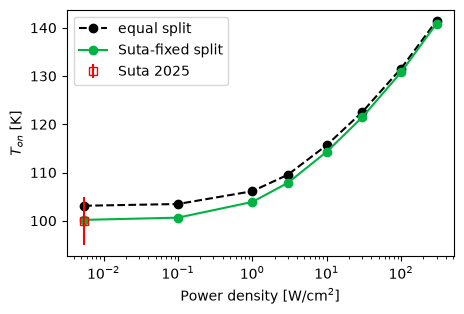

In [12]:
Ton_suta = np.array([onset(splits["Suta-fixed"], P) for P in powers])

for P, t_eq, t_s in zip(powers, Ton_P[298], Ton_suta):
    print(f"P = {P:8.4g} W/cm2   T_on equal = {t_eq:5.1f} K   T_on Suta-fixed = {t_s:5.1f} K")

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.semilogx(powers, Ton_P[298], "o--", color="black", label="equal split")
ax.semilogx(powers, Ton_suta, "o-", color=cmap["g"], label="Suta-fixed split")
ax.errorbar([suta_P], [suta_Ton], yerr=[suta_Ton_err], fmt="s", color=cmap["r"], mfc="none", label="Suta 2025")
ax.set_xlabel(r"Power density [W/cm$^2$]")
ax.set_ylabel(r"$T_{on}$ [K]")
ax.legend()
plt.show()

### Summary of the CR6 split

- **Split.** Suta's $k_1(77\ \text{K}) = 2430$ s$^{-1}$ gives $k_{cr6s} = 0.614\, k_{cr6} = 1.71 \times 10^{-17}$ cm$^3$/s and, from Anderson's constraint, $k_{cr6h} = 3.91\, k_{cr6} = 1.09 \times 10^{-16}$ cm$^3$/s, both positive (hand estimate 0.62 and 3.9). At $T_0$ the model still matches Anderson as with the equal split: green 0.998, red 1.012–1.017, blue 0.993–0.996 at 1–50 W/cm$^2$ (the red and blue offsets were already there).
- **Green kinetics vs Yu (Fig 7).** The pump-free $k_1(400)/k_1(300)$ is 3.24 with the Suta-fixed split and 2.17 with the equal split, as estimated. At 10 mJ/cm$^2$, the fluence where the model's $t_{max}(300\ \text{K})$ matches Yu's (223 vs 211 µs), the equal split follows Yu above 200 K ($\tau_R(300)/\tau_R(400)$ = 1.89 vs 1.96; $t_{max}(400)$ = 131 vs 132 µs; rms log10 0.015 in $t_{max}$, 0.049 in $\tau_R$), while the Suta-fixed split speeds the green up too much (2.71; 101 µs; rms 0.063 and 0.089). At 30 mJ/cm$^2$ both splits are too fast at 300 K (159 vs 211 µs) and the Suta-fixed ratios land closer to Yu's (2.25 vs 1.65 in $\tau_R$), so the comparison depends on Yu's unreported pulse energy.
- **Green intensity (Fig 4b).** Above 300 K the Suta-fixed split drops faster and is closer to Yu: $S(400)/S(300)$ = 0.70 vs 0.83 (Yu 0.68), but $S(350)/S(300)$ = 0.89 vs 0.95 (Yu 0.71). Below 250 K neither split reproduces Yu's rise on cooling (model ≈ 0.5 of 300 K, Yu 1.7–3.4), so the rms log10 is ≈ 0.49 for both over 10–400 K (0.18 vs 0.20 over 200–400 K).
- **$R_{HS}$ and $R_{r/g}$.** They do not depend on the split. $R_{HS}$ is below Yu's above 250 K (0.54 vs 0.80 at 400 K, rms log10 0.19). $R_{r/g}$ relative to 300 K decreases with $T$ in the model (×0.52 from 300 to 400 K) while Yu's increases (×2.86).
- **$T_{on}$.** With the Suta-fixed split $T_{on} = 100.2$ K at Suta's 5.5 mW/cm$^2$ (equal split 103.1 K; Suta $100 \pm 5$ K), about the −3 K expected from $k_1$ alone. It rises to 103.9 K at 1 W/cm$^2$, 114.3 K at 10, 130.8 K at 100 and 140.9 K at 300 W/cm$^2$. Above ~10 W/cm$^2$ the split barely matters: the ETU out of 4S3/2 dominates $k_1$.
- **Verdict.** Fixing the split with Suta's $k_1$ at 77 K reproduces $k_1$ and $T_{on}$, but it is in tension with Yu's green rise between 300 and 400 K at the fluence that matches Yu's absolute $t_{max}$: the extra 2H11/2 cross relaxation needed to keep Anderson at $T_0$ makes $k_{eff}$ grow ~40 % too fast. The equal split fits Yu's kinetics and misses Suta's $k_1$ by 27 %. The steady-state green above 300 K leans the other way, but the model misses that observable at low $T$, so it is weaker evidence.